Refiltering for the clusters since we added more attributes for the analysis.

Pleiades Filering

Columns: 
 ['source_id', 'ra', 'ra_error', 'dec', 'parallax', 'parallax_error', 'parallax_over_error', 'pm', 'pmra', 'pmdec', 'phot_g_mean_mag', 'bp_rp', 'astrometric_excess_noise', 'astrometric_excess_noise_sig', 'visibility_periods_used', 'ruwe', 'l', 'b']

Shape:  (10000, 18)
Shape after cleaning:  (8627, 18)


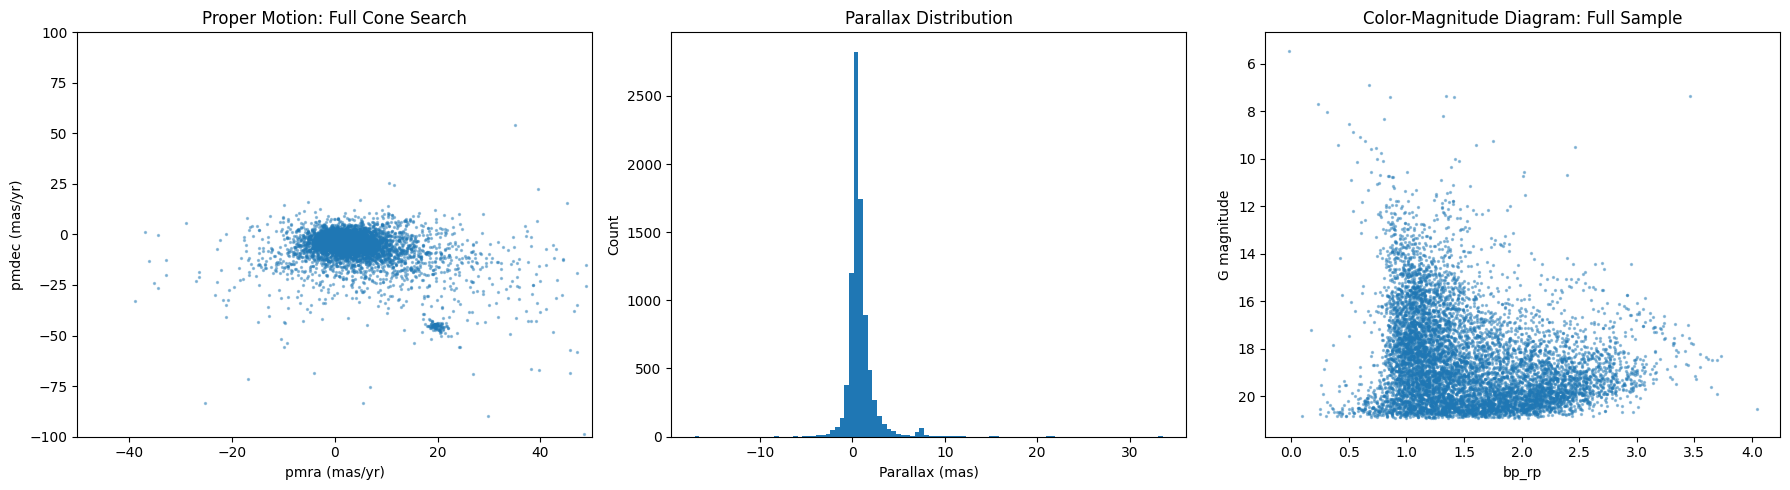

Filtered sample size:  125


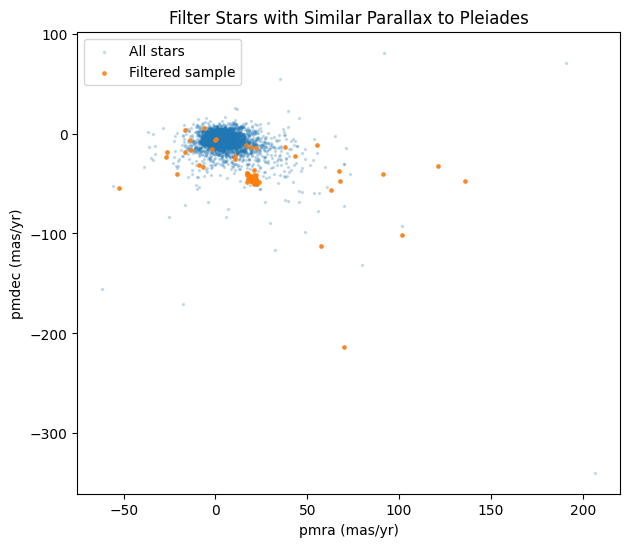

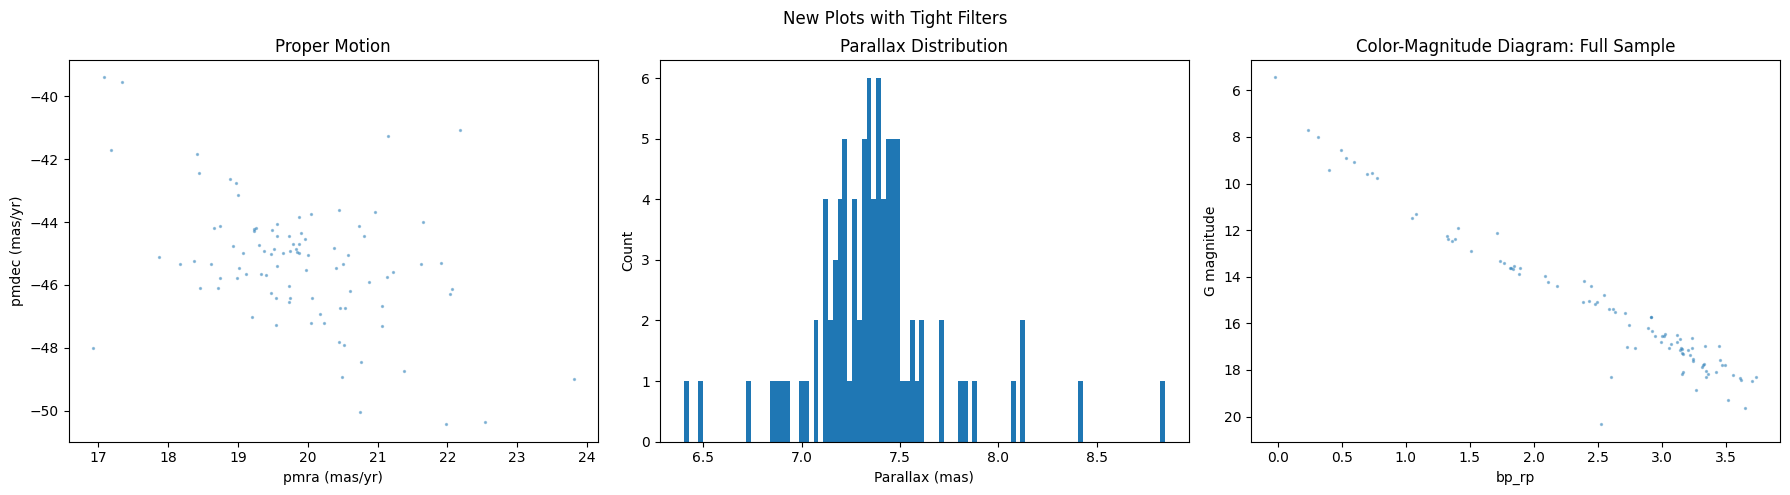


Filtered medians:
pmra   = 19.78942021617143
pmdec  = -45.302615313158384
parallax = 7.353422098732257

Robust sigmas:
pmra sigma   = 1.0682554777318172
pmdec sigma  = 1.4553594955193383
parallax sigma = 0.19175180479650147
Refined dataset size:  82
Files saved.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
data_path = "Pleiades_extra_attributes-result.csv"
df = pd.read_csv(data_path)

print("Columns: \n", df.columns.tolist())
print("\nShape: ", df.shape)

# Double check columns
cols_needed = [
    "source_id", "ra", "ra_error", "dec", "parallax", "parallax_error", 
    "parallax_over_error", "pm", "pmra", "pmdec", "phot_g_mean_mag", "bp_rp",
    "astrometric_excess_noise", "astrometric_excess_noise_sig", "visibility_periods_used", "ruwe", "l", "b"
]

df = df[[c for c in cols_needed if c in df.columns]].copy()

# convert columns to numeric
for col in df.columns:
    if col != "source_id":
        df[col] = pd.to_numeric(df[col], errors = "coerce")

# get rid of rows with missing data
df = df.dropna(subset = ["ra", "ra_error", "dec", "parallax", "parallax_error", 
    "parallax_over_error", "pm", "pmra", "pmdec", "phot_g_mean_mag", "bp_rp",
    "astrometric_excess_noise", "astrometric_excess_noise_sig", "visibility_periods_used", "ruwe", "l", "b"])

print("Shape after cleaning: ", df.shape)

# Broad plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(df["pmra"], df["pmdec"], s=2, alpha=0.4)
axes[0].set_xlabel("pmra (mas/yr)")
axes[0].set_ylabel("pmdec (mas/yr)")
axes[0].set_xlim(-50, 50)
axes[0].set_ylim(-100, 100)
axes[0].set_title("Proper Motion: Full Cone Search")

axes[1].hist(df["parallax"], bins=100)
axes[1].set_xlabel("Parallax (mas)")
axes[1].set_ylabel("Count")
axes[1].set_title("Parallax Distribution")

axes[2].scatter(df["bp_rp"], df["phot_g_mean_mag"], s=2, alpha=0.4)
axes[2].invert_yaxis()
axes[2].set_xlabel("bp_rp")
axes[2].set_ylabel("G magnitude")
axes[2].set_title("Color-Magnitude Diagram: Full Sample")

plt.tight_layout()
plt.show()

# filter based on plots
# According to `https://science.nasa.gov/missions/hubble/hubble-refines-distance-to-pleiades-star-cluster/`
# The Pleiades Star Cluster is approximately 440 light years from Earth
# 440 light years = ~135 parsec
# 135 parsec = ~0.00741 arcseconds = ~7.4 milliarcseconds parallax
# In the Parallax distribution plot we see a slight bump around 7-7.5 mas, so we can focus our filtered values in that region

filter_vals = df[
    (df["parallax"] > 6) & (df["parallax"] < 9)
].copy()

print("Filtered sample size: ", len(filter_vals))

# Plot filtered sample on top of full proper motion diagram
plt.figure(figsize=(7, 6))
plt.scatter(df["pmra"], df["pmdec"], s=2, alpha=0.2, label="All stars")
plt.scatter(filter_vals["pmra"], filter_vals["pmdec"], s=6, alpha=0.8, label="Filtered sample")
plt.xlabel("pmra (mas/yr)")
plt.ylabel("pmdec (mas/yr)")
plt.title("Filter Stars with Similar Parallax to Pleiades")
plt.legend()
plt.show()

# Overlaying stars that have a similar parallax (distance) to Pleiades with all stars in our search returns a wide cluster of stars
# But there is a very tight cluster located between 15 and 25 pmra, and -37 and -53 pmdec
# We can now filter the original dataset with these additional constraints and recreate the plots
filter_vals = df[
    (df["parallax"] > 6) & (df["parallax"] < 9) &
    (df["pmra"] > 15) & (df["pmra"] < 25) &
    (df["pmdec"] > -53) & (df["pmdec"] < -37)
].copy()

# New plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(filter_vals["pmra"], filter_vals["pmdec"], s=2, alpha=0.4)
axes[0].set_xlabel("pmra (mas/yr)")
axes[0].set_ylabel("pmdec (mas/yr)")
axes[0].set_title("Proper Motion")

axes[1].hist(filter_vals["parallax"], bins=100)
axes[1].set_xlabel("Parallax (mas)")
axes[1].set_ylabel("Count")
axes[1].set_title("Parallax Distribution")

axes[2].scatter(filter_vals["bp_rp"], filter_vals["phot_g_mean_mag"], s=2, alpha=0.4)
axes[2].invert_yaxis()
axes[2].set_xlabel("bp_rp")
axes[2].set_ylabel("G magnitude")
axes[2].set_title("Color-Magnitude Diagram: Full Sample")

plt.tight_layout()
fig.suptitle("New Plots with Tight Filters")
fig.subplots_adjust(top = 0.88)
plt.show()

# Further filter with sigma clipping in pmra, pmdec, and parallax

# use median and robust standard deviation from filtered values
def robust_sigma(x):
    mad = np.median(np.abs(x - np.median(x)))
    return 1.4826 * mad

pmra_med = filter_vals["pmra"].median()
pmdec_med = filter_vals["pmdec"].median()
parallax_med = filter_vals["parallax"].median()

pmra_sig = robust_sigma(filter_vals["pmra"])
pmdec_sig = robust_sigma(filter_vals["pmdec"])
parallax_sig = robust_sigma(filter_vals["parallax"])

print("\nFiltered medians:")
print("pmra   =", pmra_med)
print("pmdec  =", pmdec_med)
print("parallax =", parallax_med)

print("\nRobust sigmas:")
print("pmra sigma   =", pmra_sig)
print("pmdec sigma  =", pmdec_sig)
print("parallax sigma =", parallax_sig)


# cut off data more than 3 standard deviations away from medians
ref_data = df[
    (np.abs(df["pmra"] - pmra_med) < 3 * pmra_sig) &
    (np.abs(df["pmdec"] - pmdec_med) < 3 * pmdec_sig) &
    (np.abs(df["parallax"] - parallax_med) < 3 * parallax_sig) 
].copy()

print("Refined dataset size: ", len(ref_data))

# Save dataset after filter and after sigma clipping
# This produces 2 Pleiades datasets, one with 91 stars, and one with 51 stars
# 91 star dataset can be used for RQ3 (machine learning)
# Both datasets can be compared for RQ2 (visual distortions with uncertainty)
# 51 star set can be used for RQ1 (how does distance bias vary)
# ALl of this is a maybe, we might just want to use the 51 star high confidence dataset

filter_vals.to_csv("pleiades_extra_attributes.csv", index = False)

ref_data.to_csv("pleiades_extra_attributes.csv", index = False)

print("Files saved.")

Hyades Filtering

Columns: 
 ['source_id', 'ra', 'ra_error', 'dec', 'parallax', 'parallax_error', 'parallax_over_error', 'pm', 'pmra', 'pmdec', 'phot_g_mean_mag', 'bp_rp', 'astrometric_excess_noise', 'astrometric_excess_noise_sig', 'visibility_periods_used', 'ruwe', 'l', 'b']

Shape:  (8591, 18)
Shape after cleaning:  (8439, 18)


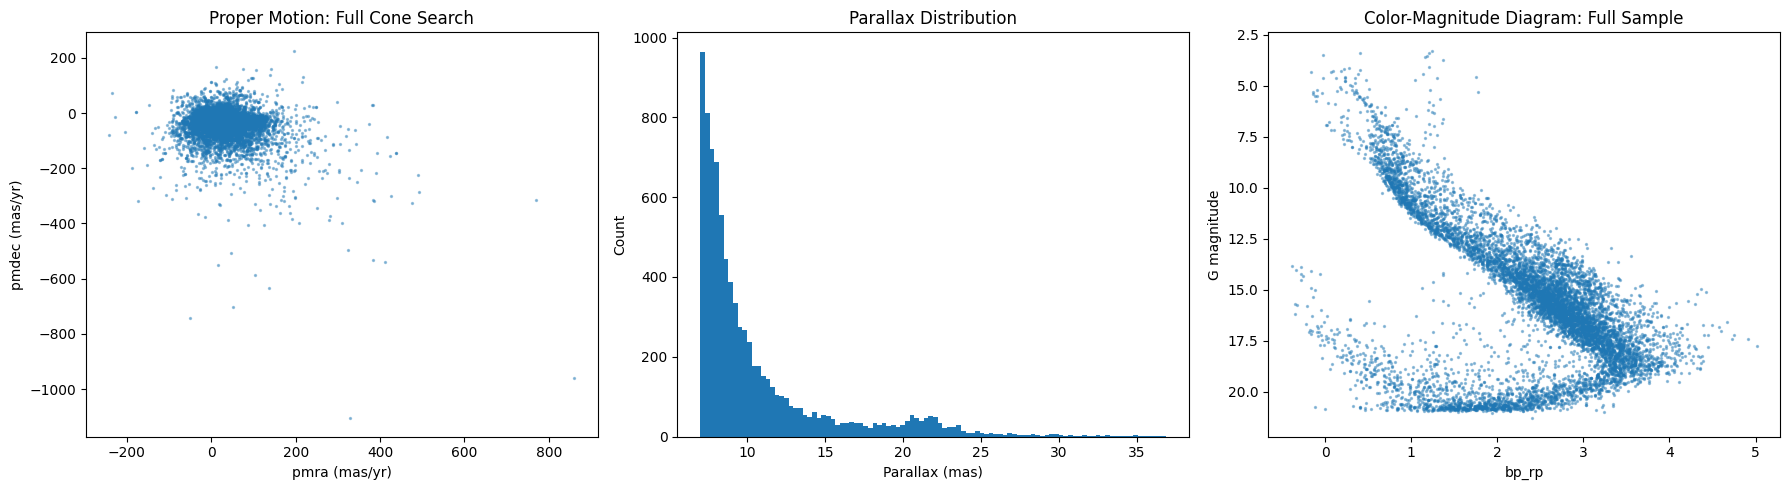

Filtered sample size:  616


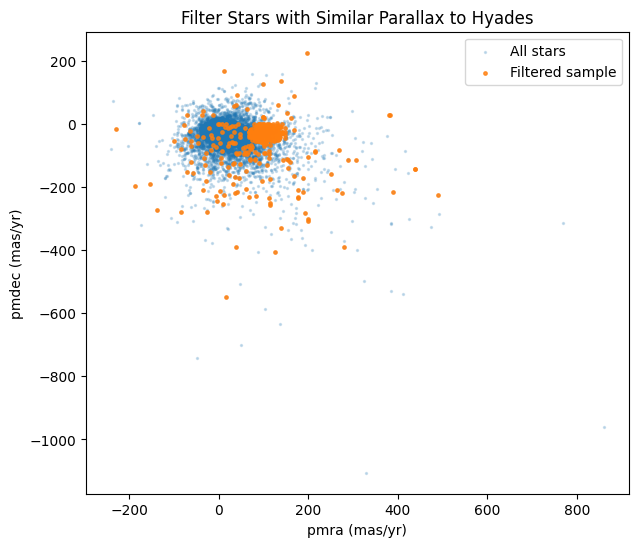

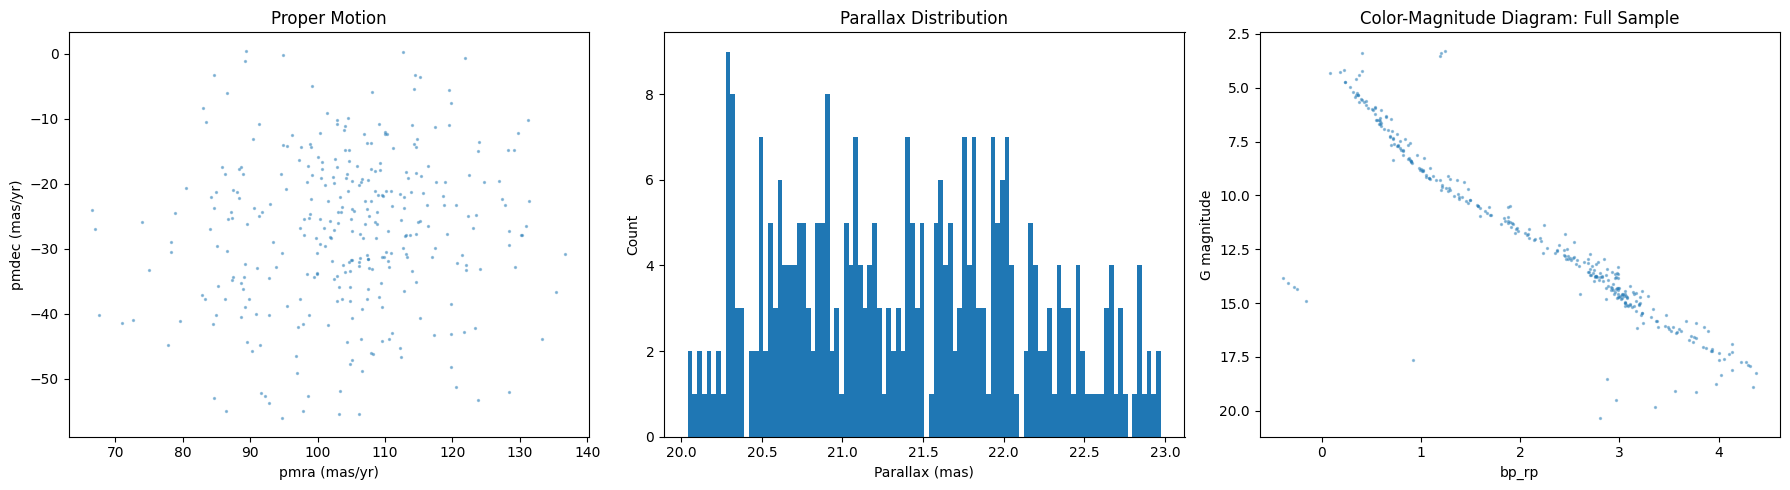


Filtered medians:
pmra   = 104.84915616019371
pmdec  = -26.28176339967887
parallax = 21.39808326312012

Robust sigmas:
pmra sigma   = 11.762373006625626
pmdec sigma  = 11.395557400705039
parallax sigma = 0.8940629959172857
Filtered dataset size:  323
Refined dataset size:  320
Files saved.


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
data_path = "Hyades_extra_attributes-result.csv"
df = pd.read_csv(data_path)

print("Columns: \n", df.columns.tolist())
print("\nShape: ", df.shape)

# Double check columns
cols_needed = [
    "source_id", "ra", "ra_error", "dec", "parallax", "parallax_error", 
    "parallax_over_error", "pm", "pmra", "pmdec", "phot_g_mean_mag", "bp_rp",
    "astrometric_excess_noise", "astrometric_excess_noise_sig", "visibility_periods_used", "ruwe", "l", "b"
]

df = df[[c for c in cols_needed if c in df.columns]].copy()

# convert columns to numeric
for col in df.columns:
    if col != "source_id":
        df[col] = pd.to_numeric(df[col], errors = "coerce")

# get rid of rows with missing data
df = df.dropna(subset = ["ra", "ra_error", "dec", "parallax", "parallax_error", 
    "parallax_over_error", "pm", "pmra", "pmdec", "phot_g_mean_mag", "bp_rp",
    "astrometric_excess_noise", "astrometric_excess_noise_sig", "visibility_periods_used", "ruwe", "l", "b"])

print("Shape after cleaning: ", df.shape)

# Broad plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(df["pmra"], df["pmdec"], s=2, alpha=0.4)
axes[0].set_xlabel("pmra (mas/yr)")
axes[0].set_ylabel("pmdec (mas/yr)")
axes[0].set_title("Proper Motion: Full Cone Search")

axes[1].hist(df["parallax"], bins=100)
axes[1].set_xlabel("Parallax (mas)")
axes[1].set_ylabel("Count")
axes[1].set_title("Parallax Distribution")

axes[2].scatter(df["bp_rp"], df["phot_g_mean_mag"], s=2, alpha=0.4)
axes[2].invert_yaxis()
axes[2].set_xlabel("bp_rp")
axes[2].set_ylabel("G magnitude")
axes[2].set_title("Color-Magnitude Diagram: Full Sample")

plt.tight_layout()
plt.show()

# According to `https://sci.esa.int/web/gaia/-/60226-the-hyades-cluster`
# The Hyades star cluster is ~150 light years from Earth
# 150 light years = ~46 parsec
# 46 parsec = ~0.02174 arseconds = ~ 21.74 milliarcseconds parallax
# Further filter parallax values to be closer to true parallax for Hyades Cluster

filter_vals = df[
    (df["parallax"] > 19) & (df["parallax"] < 25)
].copy()

print("Filtered sample size: ", len(filter_vals))

# Plot filtered sample on top of full proper motion diagram
plt.figure(figsize=(7, 6))
plt.scatter(df["pmra"], df["pmdec"], s=2, alpha=0.2, label="All stars")
plt.scatter(filter_vals["pmra"], filter_vals["pmdec"], s=6, alpha=0.8, label="Filtered sample")
plt.xlabel("pmra (mas/yr)")
plt.ylabel("pmdec (mas/yr)")
plt.title("Filter Stars with Similar Parallax to Hyades")
plt.legend()
plt.show()

# Overlay shows a tight cluster between 60-140 pmra and 10-(-60) pmdec.
# Lets filter the original dataset with these additional constraints and recreate the plots

filter_vals = df[
    (df["parallax"] > 20) & (df["parallax"] < 23) &
    (df["pmra"] > 60) & (df["pmra"] < 140) &
    (df["pmdec"] > -60) & (df["pmdec"] < 10)
].copy()

# New plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(filter_vals["pmra"], filter_vals["pmdec"], s=2, alpha=0.4)
axes[0].set_xlabel("pmra (mas/yr)")
axes[0].set_ylabel("pmdec (mas/yr)")
axes[0].set_title("Proper Motion")

axes[1].hist(filter_vals["parallax"], bins=100)
axes[1].set_xlabel("Parallax (mas)")
axes[1].set_ylabel("Count")
axes[1].set_title("Parallax Distribution")

axes[2].scatter(filter_vals["bp_rp"], filter_vals["phot_g_mean_mag"], s=2, alpha=0.4)
axes[2].invert_yaxis()
axes[2].set_xlabel("bp_rp")
axes[2].set_ylabel("G magnitude")
axes[2].set_title("Color-Magnitude Diagram: Full Sample")

plt.tight_layout()
plt.show()

# Further filter with sigma clipping in pmra, pmdec, and parallax

# use median and robust standard deviation from filtered values
def robust_sigma(x):
    mad = np.median(np.abs(x - np.median(x)))
    return 1.4826 * mad

pmra_med = filter_vals["pmra"].median()
pmdec_med = filter_vals["pmdec"].median()
parallax_med = filter_vals["parallax"].median()

pmra_sig = robust_sigma(filter_vals["pmra"])
pmdec_sig = robust_sigma(filter_vals["pmdec"])
parallax_sig = robust_sigma(filter_vals["parallax"])

print("\nFiltered medians:")
print("pmra   =", pmra_med)
print("pmdec  =", pmdec_med)
print("parallax =", parallax_med)

print("\nRobust sigmas:")
print("pmra sigma   =", pmra_sig)
print("pmdec sigma  =", pmdec_sig)
print("parallax sigma =", parallax_sig)


# cut off data that is more than 3 standard deviations away from medians
ref_data = filter_vals[
    (np.abs(filter_vals["pmra"] - pmra_med) < 3 * pmra_sig) &
    (np.abs(filter_vals["pmdec"] - pmdec_med) < 3 * pmdec_sig) &
    (np.abs(filter_vals["parallax"] - parallax_med) < 3 * parallax_sig) 
].copy()

print("Filtered dataset size: ", len(filter_vals))
print("Refined dataset size: ", len(ref_data))

# This time refined dataset and filtered dataset have approximately the same number of stars
# so we can just save the refined dataset
# It has 320 stars, which should be plenty for our analysis

ref_data.to_csv("hyades_extra_attributes.csv", index = False)

print("Files saved.")

Lasso

In [5]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score


# load data
nearby_df = pd.read_csv("nearby stars extra attributes.csv").dropna()
galactic_plane_df = pd.read_csv("galactic plane stars extra attributes.csv").dropna()
pleiades_df = pd.read_csv("pleiades_extra_attributes.csv")
hyades_df = pd.read_csv("hyades_extra_attributes.csv")

feature_cols = [
    "ra", "dec", "pm", "pmra", "pmdec", "phot_g_mean_mag", "bp_rp",
    "astrometric_excess_noise", "astrometric_excess_noise_sig",
    "visibility_periods_used", "ruwe", "l", "b"
]

# model function
def lasso(X, y, label):
    print(f"\n{label}:")

    # train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # LassoCV model
    lasso = LassoCV(
        cv=10,
        n_alphas=200,
        max_iter=5000,
        random_state=42
    )

    # fit model
    lasso.fit(X_train_scaled, y_train)

    # predictions
    y_pred = lasso.predict(X_test_scaled)

    # metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    # output
    print("Non-zero coefficients:", np.sum(lasso.coef_ != 0))
    print("R^2:", r2)
    print("RMSE:", rmse)

    # feature importance
    coef = lasso.coef_
    importance_df = pd.DataFrame({
        "feature": feature_cols,
        "coefficient": coef,
        "abs_importance": np.abs(coef)
    }).sort_values("abs_importance", ascending=False)

    print("\nFeature importance (sorted):")
    print(importance_df)

    selected = importance_df[importance_df["coefficient"] != 0]["feature"].tolist()
    print("\nSelected features:", selected)

    # return model and scaler
    return lasso, scaler, importance_df

# run model for each group
nearby_model, nearby_scaler, nearby_lasso_importance = lasso(
    nearby_df[feature_cols], nearby_df["parallax_error"], "Nearby Stars"
)

galactic_plane_model, galactic_plane_scaler, galactic_plane_lasso_importance = lasso(
    galactic_plane_df[feature_cols], galactic_plane_df["parallax_error"], "Galactic Plane"
)

pleiades_model, pleiades_scaler, pleiades_lasso_importance = lasso(
    pleiades_df[feature_cols], pleiades_df["parallax_error"], "Pleiades"
)

hyades_model, hyades_scaler, hyades_lasso_importance = lasso(
    hyades_df[feature_cols], hyades_df["parallax_error"], "Hyades"
)


Nearby Stars:


c:\Users\annap\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1663: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(


Non-zero coefficients: 12
R^2: 0.8395247787139586
RMSE: 0.02194292181091028

Feature importance (sorted):
                         feature   coefficient  abs_importance
7       astrometric_excess_noise  4.357595e-02    4.357595e-02
5                phot_g_mean_mag  2.648303e-02    2.648303e-02
9        visibility_periods_used -6.568238e-03    6.568238e-03
8   astrometric_excess_noise_sig  5.204937e-03    5.204937e-03
12                             b  4.600218e-03    4.600218e-03
10                          ruwe -2.569329e-03    2.569329e-03
1                            dec -2.274996e-03    2.274996e-03
6                          bp_rp -2.201302e-03    2.201302e-03
0                             ra -1.776990e-03    1.776990e-03
2                             pm -6.939104e-04    6.939104e-04
3                           pmra  2.351693e-04    2.351693e-04
4                          pmdec  5.170365e-07    5.170365e-07
11                             l -0.000000e+00    0.000000e+00

Selected fe

c:\Users\annap\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1663: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(


Non-zero coefficients: 11
R^2: 0.879525267766391
RMSE: 0.020258614140803856

Feature importance (sorted):
                         feature  coefficient  abs_importance
7       astrometric_excess_noise     0.040231        0.040231
5                phot_g_mean_mag     0.031593        0.031593
9        visibility_periods_used    -0.007391        0.007391
10                          ruwe     0.006041        0.006041
12                             b    -0.001536        0.001536
6                          bp_rp     0.001083        0.001083
8   astrometric_excess_noise_sig     0.000911        0.000911
0                             ra     0.000867        0.000867
2                             pm     0.000527        0.000527
3                           pmra    -0.000416        0.000416
4                          pmdec     0.000057        0.000057
1                            dec    -0.000000        0.000000
11                             l     0.000000        0.000000

Selected features: ['astr

c:\Users\annap\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1663: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(


Non-zero coefficients: 3
R^2: 0.6749407275116044
RMSE: 0.03789957434345879

Feature importance (sorted):
                         feature  coefficient  abs_importance
7       astrometric_excess_noise     0.058570        0.058570
5                phot_g_mean_mag     0.034582        0.034582
0                             ra    -0.001702        0.001702
1                            dec     0.000000        0.000000
2                             pm    -0.000000        0.000000
4                          pmdec     0.000000        0.000000
3                           pmra     0.000000        0.000000
6                          bp_rp     0.000000        0.000000
8   astrometric_excess_noise_sig     0.000000        0.000000
9        visibility_periods_used    -0.000000        0.000000
10                          ruwe    -0.000000        0.000000
11                             l    -0.000000        0.000000
12                             b    -0.000000        0.000000

Selected features: ['astro

c:\Users\annap\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1663: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(


Non-zero coefficients: 8
R^2: 0.9621114889761626
RMSE: 0.025047368033300065

Feature importance (sorted):
                         feature  coefficient  abs_importance
7       astrometric_excess_noise     0.130642        0.130642
10                          ruwe    -0.027775        0.027775
5                phot_g_mean_mag     0.023334        0.023334
9        visibility_periods_used    -0.012038        0.012038
0                             ra     0.008795        0.008795
6                          bp_rp    -0.006640        0.006640
11                             l     0.003657        0.003657
8   astrometric_excess_noise_sig    -0.001666        0.001666
1                            dec    -0.000000        0.000000
4                          pmdec     0.000000        0.000000
3                           pmra     0.000000        0.000000
2                             pm     0.000000        0.000000
12                             b     0.000000        0.000000

Selected features: ['astr

Gradient Boosting


Nearby Stars:
R^2: 0.9775469262825428
RMSE: 0.008207830232687598

Top features:
                         feature  importance
7       astrometric_excess_noise    0.625055
5                phot_g_mean_mag    0.353383
9        visibility_periods_used    0.018054
0                             ra    0.000809
10                          ruwe    0.000611
6                          bp_rp    0.000574
8   astrometric_excess_noise_sig    0.000424
1                            dec    0.000318
12                             b    0.000286
11                             l    0.000259
3                           pmra    0.000113
2                             pm    0.000065
4                          pmdec    0.000049


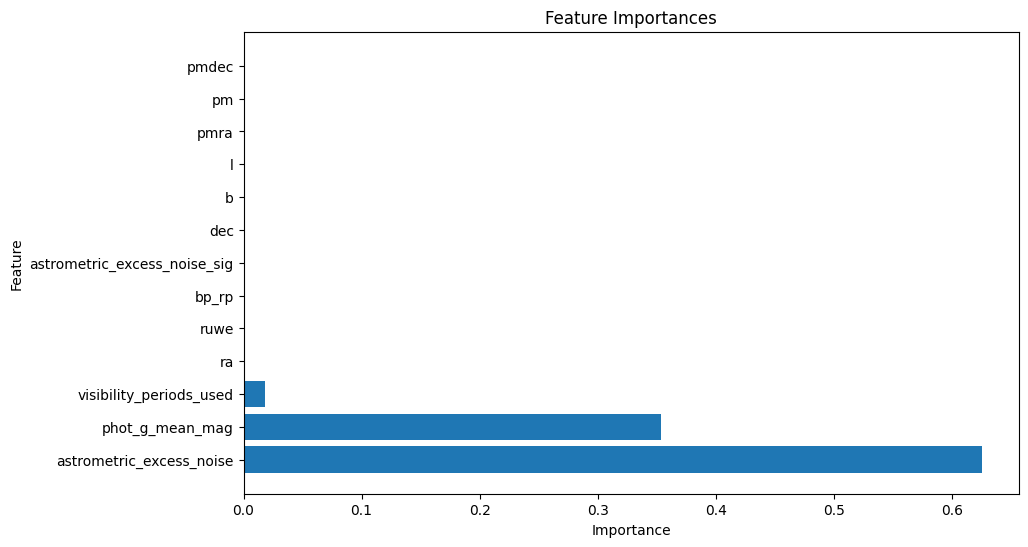


Galactic Plane:
R^2: 0.9802539315736271
RMSE: 0.008201665759625958

Top features:
                         feature  importance
7       astrometric_excess_noise    0.591564
5                phot_g_mean_mag    0.384424
9        visibility_periods_used    0.018607
12                             b    0.002584
0                             ra    0.000685
1                            dec    0.000595
10                          ruwe    0.000432
8   astrometric_excess_noise_sig    0.000296
11                             l    0.000280
3                           pmra    0.000247
4                          pmdec    0.000161
6                          bp_rp    0.000086
2                             pm    0.000039


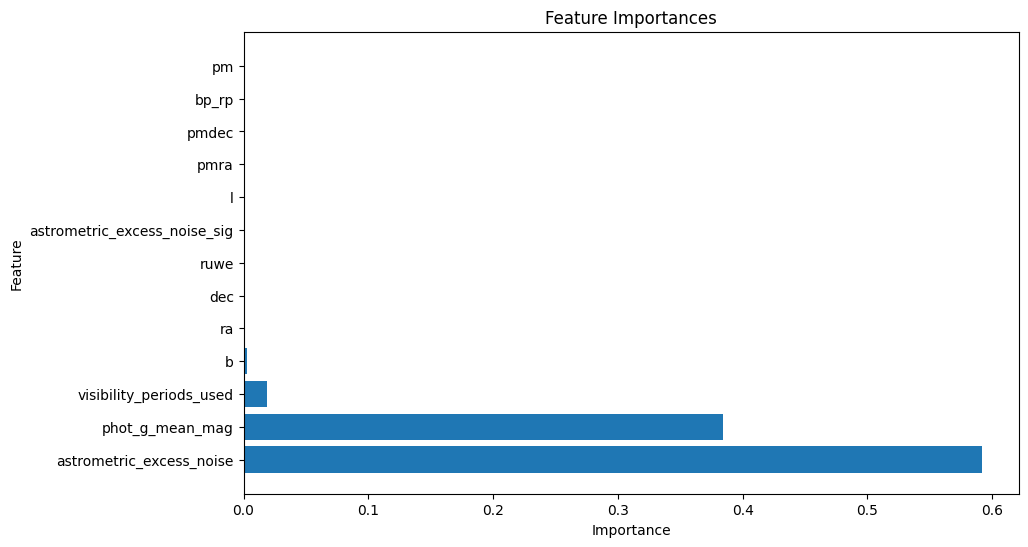


Pleiades:
R^2: 0.9272013951124494
RMSE: 0.0179355451317904

Top features:
                         feature  importance
5                phot_g_mean_mag    0.437745
7       astrometric_excess_noise    0.280365
6                          bp_rp    0.163691
0                             ra    0.031318
8   astrometric_excess_noise_sig    0.026146
3                           pmra    0.021447
12                             b    0.011406
4                          pmdec    0.010470
10                          ruwe    0.009118
9        visibility_periods_used    0.002921
1                            dec    0.002026
2                             pm    0.001693
11                             l    0.001653


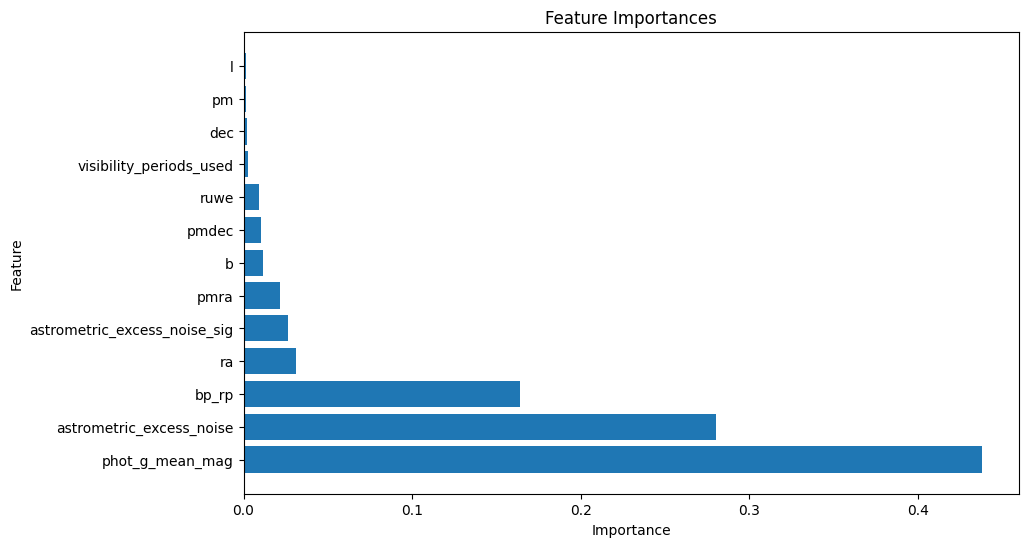


Hyades:
R^2: 0.9741740908414956
RMSE: 0.02067931446661612

Top features:
                         feature  importance
7       astrometric_excess_noise    0.822039
5                phot_g_mean_mag    0.066299
9        visibility_periods_used    0.024844
8   astrometric_excess_noise_sig    0.022218
6                          bp_rp    0.013047
10                          ruwe    0.012180
3                           pmra    0.012017
11                             l    0.011036
12                             b    0.006437
0                             ra    0.006246
1                            dec    0.001973
4                          pmdec    0.000920
2                             pm    0.000744


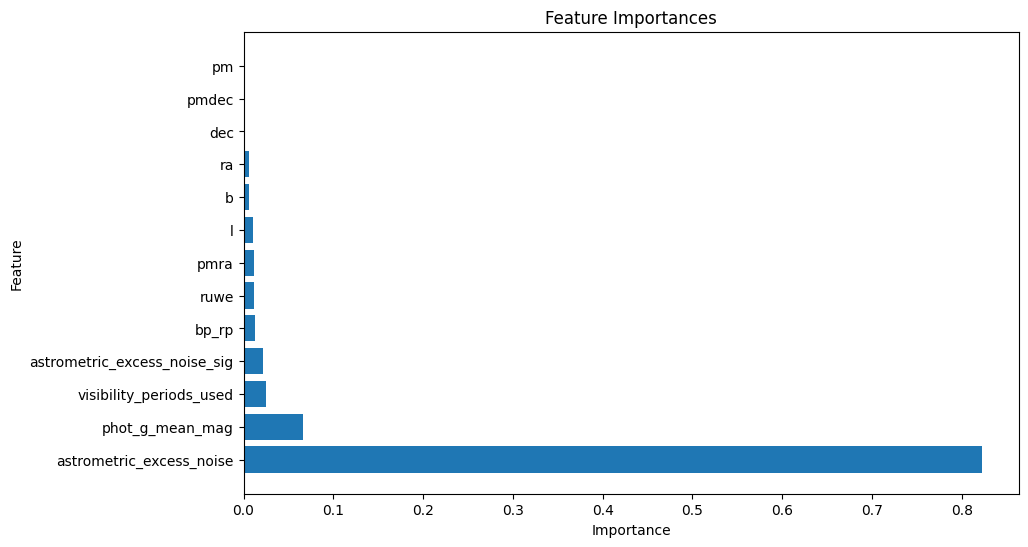

In [3]:
import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# load data
nearby_df = pd.read_csv("nearby stars extra attributes.csv").dropna()
galactic_plane_df = pd.read_csv("galactic plane stars extra attributes.csv").dropna()
pleiades_df = pd.read_csv("pleiades_extra_attributes.csv").dropna()
hyades_df = pd.read_csv("hyades_extra_attributes.csv").dropna()

feature_cols = [
    "ra", "dec", "pm", "pmra", "pmdec", "phot_g_mean_mag", "bp_rp",
    "astrometric_excess_noise", "astrometric_excess_noise_sig",
    "visibility_periods_used", "ruwe", "l", "b"
]

# Gradient Boosting function
def gbr(X, y, label):
    print(f"\n{label}:")

    # train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Gradient Boosting Regressor
    gbr = GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.8,
        random_state=42
    )

    # fit model
    gbr.fit(X_train_scaled, y_train)

    # predict
    y_pred = gbr.predict(X_test_scaled)

    # metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    # output
    print("R^2:", r2)
    print("RMSE:", rmse)

    # feature importance
    importances = gbr.feature_importances_
    importance_df = pd.DataFrame({
        "feature": feature_cols,
        "importance": importances
    }).sort_values("importance", ascending=False)

    print("\nTop features:")
    print(importance_df)


    import matplotlib.pyplot as plt
    # Plot feature importance
    plt.figure(figsize=(10, 6))
    plt.barh(importance_df['feature'], importance_df['importance'])
    plt.title('Feature Importances')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.show()

    return gbr, scaler, importance_df

# run models for each group

nearby_model, nearby_scaler, nearby_gbr_importance = gbr(
    nearby_df[feature_cols], nearby_df["parallax_error"], "Nearby Stars"
)

galactic_plane_model, galactic_plane_scaler, galactic_plane_gbr_importance = gbr(
    galactic_plane_df[feature_cols], galactic_plane_df["parallax_error"], "Galactic Plane"
)

pleiades_model, pleiades_scaler, pleiades_gbr_importance = gbr(
    pleiades_df[feature_cols], pleiades_df["parallax_error"], "Pleiades"
)

hyades_model, hyades_scaler, hyades_gbr_importance = gbr(
    hyades_df[feature_cols], hyades_df["parallax_error"], "Hyades"
)

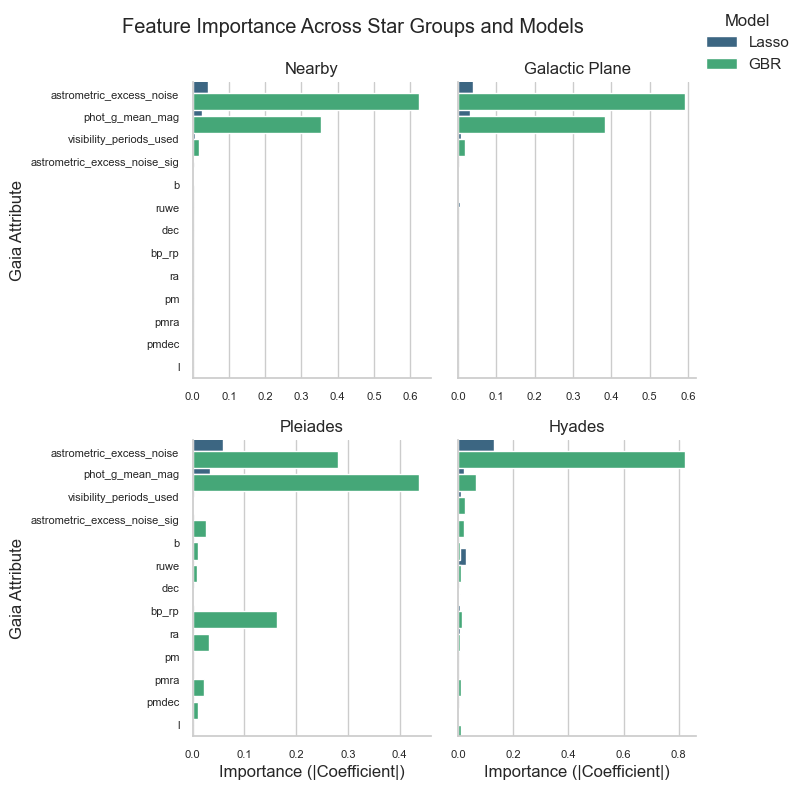

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

def format_importance(df, cluster, method, value_col):
    out = df.copy()
    out["cluster"] = cluster
    out["method"] = method
    out = out.rename(columns={value_col: "importance"})
    return out[["feature", "importance", "cluster", "method"]]

all_importances = pd.concat([
    format_importance(nearby_lasso_importance, "Nearby", "Lasso", "abs_importance"),
    format_importance(galactic_plane_lasso_importance, "Galactic Plane", "Lasso", "abs_importance"),
    format_importance(pleiades_lasso_importance, "Pleiades", "Lasso", "abs_importance"),
    format_importance(hyades_lasso_importance, "Hyades", "Lasso", "abs_importance"),

    format_importance(nearby_gbr_importance, "Nearby", "GBR", "importance"),
    format_importance(galactic_plane_gbr_importance, "Galactic Plane", "GBR", "importance"),
    format_importance(pleiades_gbr_importance, "Pleiades", "GBR", "importance"),
    format_importance(hyades_gbr_importance, "Hyades", "GBR", "importance"),
])


sns.set_theme(style="whitegrid")

g = sns.catplot(
    data=all_importances,
    kind="bar",
    x="importance",
    y="feature",
    hue="method",
    col="cluster",
    col_wrap=2,
    height=4,
    sharex=False,
    palette="viridis"
)

g._legend.set_title("Model")
g._legend.set_loc("upper right")

for ax in g.axes.flatten():
    ax.tick_params(axis='y', labelsize=8)
    ax.tick_params(axis='x', labelsize=8)


g.set_axis_labels("Importance (|Coefficient|)", "Gaia Attribute")
g.set_titles("{col_name}")  # keeps each facet titled by cluster name

g.fig.subplots_adjust(top=0.9)
g.fig.suptitle("Lasso Feature Importance Across Star Groups")


g.fig.subplots_adjust(top=0.9)
g.fig.suptitle("Feature Importance Across Star Groups and Models")
plt.show()
